<a href="https://colab.research.google.com/github/Yash1014-code/flyrank-internship-ml/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Yash1014-code/flyrank-internship-ml/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

## Research Question

Can a machine-learning model use historical search-performance signals to rank content pages by their expected future click-through rate (CTR), and does this ranking provide a useful improvement over the transparent Week 4 baseline for prioritizing pages for human review?


The project evaluates whether historical search and engagement signals can provide a practical ranking signal for content prioritization. The focus is on ranking pages for review rather than automatically changing content, and the evaluation is designed to respect the time ordering of the data.


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

This study uses the FlyRank ML Internship dataset and the documented warehouse release used in the preceding experiments. The analysis combines historical Google Search Console (GSC) search-performance signals with available Google Analytics 4 (GA4) engagement signals at the content-page level.

The modeling workflow uses time-ordered monthly data. February data is used to construct training features and March is used for development/evaluation of the forward CTR target, while the final time-aware evaluation uses March features to predict April future CTR. A separate grouped + time-aware validation was also performed to test the ranking signal on clients that were not present in training.

The analysis excludes information that would only be available after the prediction point, including future target values, April-derived features during model development, decision-derived fields, and identifiers as model features. Features that could directly reveal the target or introduce temporal leakage were not used.

The dataset contains search and engagement measurements such as impressions, clicks, sessions, average search position, CTR-related signals, and content-level attributes. The analysis is intended for aggregate research and decision-support purposes; individual client identities, private queries, URLs, and other non-public information are not part of the public-facing paper.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

Prediction target

The model predicts future monthly click-through rate (CTR) using information available before the prediction period. The target is therefore defined from a future time window rather than from the same period as the input features.

Features

The Random Forest model uses five historical search and engagement features:

gsc_avg_position
gsc_impressions
gsc_clicks
ga4_sessions
scroll_events

The model was selected as the learned ranking approach for comparison with the transparent Week 4 baseline.

Baseline

The Week 4 baseline is a transparent rule-based score designed to prioritize pages that are old while retaining meaningful search visibility. It provides an interpretable reference point against which the learned model can be compared.

Validation design

The primary evaluation follows a forward-in-time design: February information is used for model development and March information is used to evaluate the forward-looking CTR task, with the final reported model evaluation using March features and April future CTR.

A second validation uses both time ordering and client grouping. In this evaluation, the held-out clients are not present in the training data, providing an additional test of whether the ranking signal persists beyond clients seen during training.

Leakage checks

The validation audit checks that:

the target is not included among model features;
future-period features are not used;
decision-derived fields are excluded;
identifiers are not used as model features; and
required model features do not contain missing values.

The Week 6 leakage audit passed these checks.

Evaluation

Model quality is evaluated using MAE, RMSE, and Spearman rank correlation. For prioritization, the model and baseline are also compared using the mean future CTR among the highest-ranked pages at Top-20, Top-100, and Top-500.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*
The Random Forest produced a measurable ranking signal on the forward-looking evaluation period. On the March-to-April evaluation set, the model achieved an MAE of 0.004545, RMSE of 0.025830, and Spearman rank correlation of 0.174270. The Week 4 baseline had a Spearman rank correlation of 0.169878 on the same evaluation population.

For the prioritization analysis, the mean future CTR among the highest-ranked pages was compared between the Random Forest and the baseline using the same evaluation population. At Top-20, the model's mean future CTR was 0.065211, compared with 0.000627 for the baseline. At Top-100, it was 0.055425 compared with 0.000731, and at Top-500, 0.034707 compared with 0.000689.

These results indicate that the learned model produced a stronger observed ranking signal than the transparent baseline on this evaluation. The comparison is descriptive and measured on the available evaluation data; it does not establish that using the model will cause CTR to increase after a content refresh.

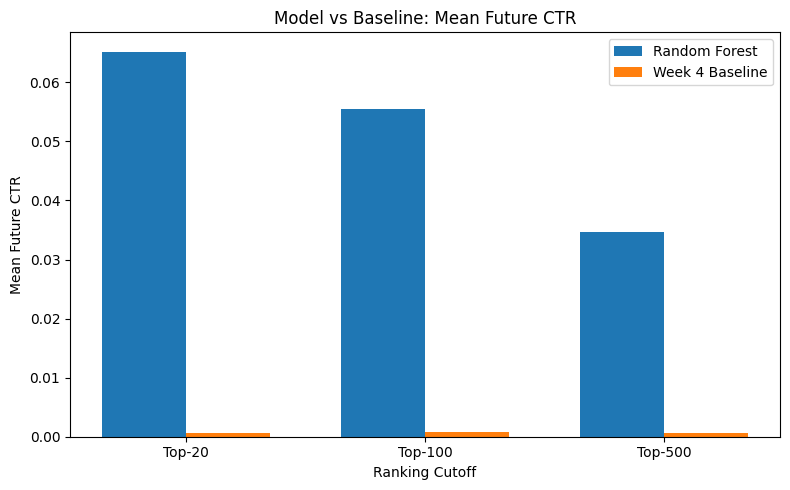

Chart 1 saved successfully.


In [15]:
import os
import matplotlib.pyplot as plt

# Create the figures directory
os.makedirs("./work/figures", exist_ok=True)

top_k = [20, 100, 500]
model_ctr = [0.065211, 0.055425, 0.034707]
baseline_ctr = [0.000627, 0.000731, 0.000689]

x = range(len(top_k))
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(
    [i - width/2 for i in x],
    model_ctr,
    width=width,
    label="Random Forest"
)

plt.bar(
    [i + width/2 for i in x],
    baseline_ctr,
    width=width,
    label="Week 4 Baseline"
)

plt.xticks(x, [f"Top-{k}" for k in top_k])
plt.ylabel("Mean Future CTR")
plt.xlabel("Ranking Cutoff")
plt.title("Model vs Baseline: Mean Future CTR")
plt.legend()
plt.tight_layout()

plt.savefig(
    "./work/figures/w08_model_vs_baseline.png",
    dpi=160,
    bbox_inches="tight"
)

plt.show()

print("Chart 1 saved successfully.")

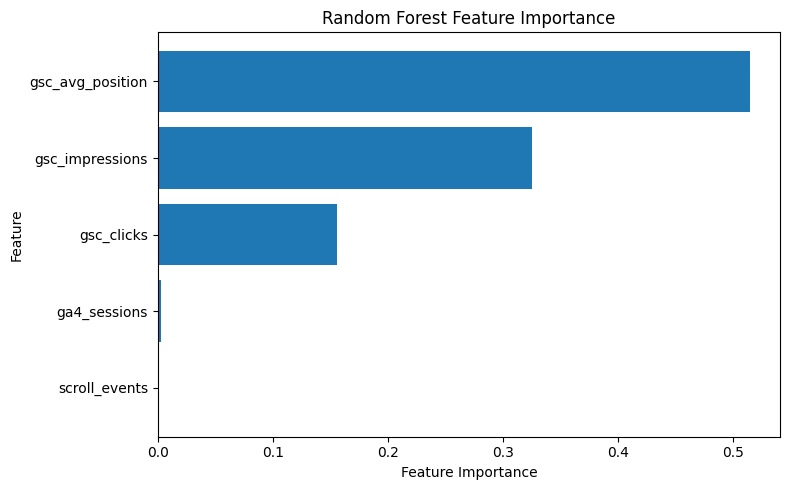

Chart 2 saved successfully.


In [16]:
import matplotlib.pyplot as plt

features = [
    "gsc_avg_position",
    "gsc_impressions",
    "gsc_clicks",
    "ga4_sessions",
    "scroll_events"
]

importance = [
    0.515397,
    0.325163,
    0.156110,
    0.002836,
    0.000495
]

plt.figure(figsize=(8, 5))

plt.barh(features[::-1], importance[::-1])

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.tight_layout()

plt.savefig(
    "./work/figures/w08_feature_importance.png",
    dpi=160,
    bbox_inches="tight"
)

plt.show()

print("Chart 2 saved successfully.")

**Chart 1 takeaway:** The Random Forest's highest-ranked pages had higher observed mean future CTR than the Week 4 baseline at all three evaluated ranking cutoffs.

**Chart 2 takeaway:** Search-position and search-visibility features contributed most strongly to the Random Forest's predictions, while the GA4 and scroll features had very small feature-importance values.


## 5. Limitations

*What this work cannot claim.*
## Limitations & Honest Framing

The results should be interpreted as an observed ranking signal on the evaluated data, not as causal evidence that the model will increase CTR or improve search performance after a content change.

The evaluation is based on historical observational data. The model identifies patterns associated with future CTR, but the analysis does not establish that changing a page because it received a high priority score will cause its future CTR to increase.

The grouped + time-aware validation provides an additional test using clients held out from training, but it does not establish universal generalization to all websites, industries, or future search environments.

The model also relies heavily on search-performance variables, particularly average search position and impressions. The very small feature-importance values for the GA4 and scroll features indicate that these additional engagement signals contributed relatively little to this particular Random Forest model.

Search behavior, content quality, competition, and external factors can change over time. Therefore, the ranking should be treated as decision support that requires human review rather than an autonomous content-optimization system.

No automatic publishing, rewriting, deletion, redirect, or guaranteed performance improvement is implied by the recommendations.


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*


The model output is converted into a ranked action queue for human review. The ranking is intended to help analysts decide which pages to inspect first, rather than to automatically modify content.

### 1. Review high-priority pages with strong search visibility

Pages receiving high refresh priority and showing meaningful search visibility should be reviewed first. The review should check whether the content is outdated, whether the page still matches search intent, and whether an update could be justified.

### 2. Investigate pages showing stale-content signals

Pages with older content or a long time since their last update should receive additional review when they also retain meaningful search visibility. These pages represent potential refresh candidates, but the score alone should not determine whether a refresh is performed.

### 3. Review low-visibility pages cautiously

Older pages with weak search visibility should not automatically receive the same level of investment. Review their relevance, business value, search intent, and potential alternatives before allocating significant refresh effort.

### 4. Avoid unnecessary changes to fresh, visible pages

Pages that are relatively fresh and already maintain meaningful visibility should not be changed solely because they appear in the ranking. A separate content or business issue should justify intervention.

### Human-review checklist

Before taking action, reviewers should:

1. Check search intent and page relevance.
2. Check whether the content is outdated.
3. Check current search visibility.
4. Consider consolidation or redirect alternatives.
5. Check seasonality or recent search changes.
6. Consider relevant business context.

The ranked queue is therefore an **analyst prioritization tool**, not an automated content-management system.


In [17]:
import pandas as pd

queue = pd.read_csv("/content/w07_ranked_action_queue.csv")

print(queue.shape)
print(queue.columns.tolist())

(200, 28)
['final_rank', 'content_id', 'client_id', 'final_refresh_score', 'best_model_name', 'best_model_probability', 'baseline_refresh_score', 'confidence', 'suggested_action', 'final_reason_codes', 'is_declining_label', 'impressions_90d', 'clicks_90d', 'sessions_90d', 'avg_position', 'ctr', 'content_age_days', 'days_since_last_update', 'word_count', 'trend_direction', 'competition_level', 'content_type', 'main_intent', 'age_tier', 'freshness_tier', 'word_count_tier', 'impression_tier', 'position_tier']


In [18]:
summary_columns = [
    "final_rank",
    "final_refresh_score",
    "confidence",
    "suggested_action"
]

display(
    queue[summary_columns]
    .sort_values("final_rank")
    .head(20)
)

,final_rank,final_refresh_score,confidence,suggested_action
0,1,81.636697,high,refresh_and_review_ctr
1,2,81.447656,high,refresh_and_review_ctr
2,3,81.430346,medium,refresh_and_review_ctr
3,4,81.034960,high,refresh_and_review_ctr
4,5,80.873188,medium,refresh_and_review_ctr
5,6,80.754770,high,refresh_and_review_ctr
6,7,80.632923,high,refresh_and_review_ctr
7,8,80.371236,high,refresh_and_review_ctr
8,9,80.362748,medium,refresh_and_review_ctr
9,10,80.321757,medium,refresh


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*
The project produces the following research artifacts:

Week 5 model notebook: work/notebooks/w05_model.ipynb
Week 6 validation audit: work/notebooks/w06_validation_audit.ipynb
Week 7 action playbook: work/notebooks/w07_action_playbook_completed.ipynb
Week 7 ranked action queue: work/outputs/w07_ranked_action_queue.csv
Week 7 playbook metrics receipt: work/outputs/w07_playbook_metrics.json
Week 7 action-distribution figure: work/figures/w07_action_distribution.png
Week 8 model-vs-baseline figure: work/figures/w08_model_vs_baseline.png
Week 8 feature-importance figure: work/figures/w08_feature_importance.png

The notebooks document the data preparation, modeling, validation, leakage checks, and action-playbook workflow used to produce the results.

The ranked queue is intended for analyst inspection and human decision-making. The public-facing research artifact should not expose private client information, URLs, queries, or other non-public identifiers.

# ML-12 — 5-Minute Demo Outline

### 0:00–0:45 — Problem

Explain the content-refresh prioritization problem: when an SEO/content team has many pages to review, the goal is to identify which pages should be examined first using observable historical search and engagement signals.

### 0:45–1:30 — Data and target

Introduce the pseudonymized FlyRank warehouse data and explain the prediction setup.

The model uses information available during the March 2026 feature window to estimate future April CTR. The evaluation is performed on pages with an observed April outcome.

### 1:30–2:15 — Baseline

Show the transparent Week 4 baseline.

The baseline prioritizes pages using content age and meaningful search visibility. It provides an interpretable reference point for evaluating whether the learned model adds useful ranking signal.

### 2:15–3:15 — Model and validation

Explain the Random Forest Regressor and the time-aware evaluation design.

The model is developed using the earlier February → March window and evaluated on the March → April future window.

Key results:

* Random Forest MAE: **0.004545**
* Random Forest RMSE: **0.025830**
* Random Forest Spearman correlation: **0.174270**
* Week 4 baseline Spearman correlation: **0.169878**

The model and baseline are evaluated on the same March → April population.

### 3:15–4:00 — Ranking signal and interpretation

Show the Top-K comparison and feature-importance chart.

The Random Forest produced higher observed mean future CTR among the highest-ranked pages at Top-20, Top-100, and Top-500 in this evaluation.

The strongest model features were `gsc_avg_position`, `gsc_impressions`, and `gsc_clicks`.

Emphasize that these are observed associations in the evaluation data, not evidence of causal CTR improvement.

### 4:00–5:00 — Action playbook

Show the ranked action queue, reason-code distribution, and human-review workflow.

Explain that the output is designed to prioritize pages for analyst review. A high ranking does not guarantee that refreshing a page will improve its future performance.

End with the main conclusion:

The Random Forest showed a modestly higher observed ranking correlation than the transparent Week 4 baseline in the tested future window. The resulting system is therefore best framed as decision-support for prioritizing human review, not as an automatic content-refresh system.


Built an end-to-end ML workflow for content-refresh prioritization during the FlyRank ML Internship.

The project covered research-question framing, data contracts, leakage checks, a transparent ranking baseline, Random Forest modeling, time-aware future-window evaluation, feature analysis, and a ranked action playbook.

The Random Forest achieved a Spearman rank correlation of 0.17427 compared with 0.169878 for the Week 4 baseline on the same March → April evaluation population.

The more important lesson was how to interpret that result carefully: a modestly stronger ranking signal does not prove that refreshing a page will cause higher CTR.

The final workflow produces ranked recommendations for human review, with reason codes and explicit safeguards against leakage, overclaiming, and automatic content decisions.


I built an end-to-end content-prioritization workflow using a transparent baseline and a Random Forest Regressor evaluated with a time-aware future-window design. On the March → April evaluation population, the model achieved a Spearman rank correlation of 0.17427 compared with 0.169878 for the Week 4 baseline, while also producing Top-K ranking and feature-importance analysis. The final output is a reproducible ranked review queue designed for human decision-support, with leakage checks and explicit safeguards against causal overclaiming and automatic content changes.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
